In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

sentence_a = "John gave Mary the book and then John gave"
sentence_b = "Tom gave Mary the book and then Tom gave"

inputs_a = tokenizer(sentence_a, return_tensors="pt")
inputs_b = tokenizer(sentence_b, return_tensors="pt")

mary_id = tokenizer.encode(" Mary")[0]

with torch.no_grad():
    out_a = model(**inputs_a)
    out_b = model(**inputs_b)

probs_a = torch.softmax(out_a.logits[0, -1, :], dim=0)
probs_b = torch.softmax(out_b.logits[0, -1, :], dim=0)

print(f"Baseline A P(Mary): {probs_a[mary_id]:.4f}")
print(f"Baseline B P(Mary): {probs_b[mary_id]:.4f}")

# Attention outputs capture karo
attn_outputs_a = {}

def make_capture_hook(layer_idx):
    def hook(module, input, output):
        attn_outputs_a[layer_idx] = output[0].detach().clone()
    return hook

hooks = []
for i in range(12):
    h = model.transformer.h[i].attn.register_forward_hook(
        make_capture_hook(i))
    hooks.append(h)

with torch.no_grad():
    model(**inputs_a)

for h in hooks:
    h.remove()

print(f"\nCaptured {len(attn_outputs_a)} attention outputs!")
print(f"Shape: {attn_outputs_a[0].shape}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5141.10it/s]


Baseline A P(Mary): 0.2258
Baseline B P(Mary): 0.2510

Captured 12 attention outputs!
Shape: torch.Size([1, 9, 768])


In [2]:
head_dim = model.config.n_embd // model.config.n_head  # 64

kl_matrix = torch.zeros(12, 12)  # [layers, heads]

for layer_idx in range(12):
    target = attn_outputs_a[layer_idx].clone()
    
    for head_idx in range(12):
        start = head_idx * head_dim
        end   = start + head_dim
        
        def patch_head_hook(module, input, output):
            patched = output[0].clone()
            # Sirf is head ko patch karo
            patched[0, -1, start:end] = target[0, -1, start:end]
            return (patched,) + output[1:]
        
        hook = model.transformer.h[layer_idx].attn.register_forward_hook(
            patch_head_hook)
        
        with torch.no_grad():
            patched_out = model(**inputs_b)
        
        hook.remove()
        
        patched_probs = torch.softmax(
            patched_out.logits[0, -1, :], dim=0)
        mary_prob = patched_probs[mary_id].item()
        
        kl_matrix[layer_idx, head_idx] = mary_prob

    print(f"Layer {layer_idx+1} done!")

print(f"\nBaseline B P(Mary): {probs_b[mary_id]:.4f}")
print(f"Max P(Mary): {kl_matrix.max():.4f} at "
      f"L{kl_matrix.max(dim=1).values.argmax()+1}, "
      f"H{kl_matrix.max(dim=0).values.argmax()}")

Layer 1 done!
Layer 2 done!
Layer 3 done!
Layer 4 done!
Layer 5 done!
Layer 6 done!
Layer 7 done!
Layer 8 done!
Layer 9 done!
Layer 10 done!
Layer 11 done!
Layer 12 done!

Baseline B P(Mary): 0.2510
Max P(Mary): 0.2701 at L8, H4


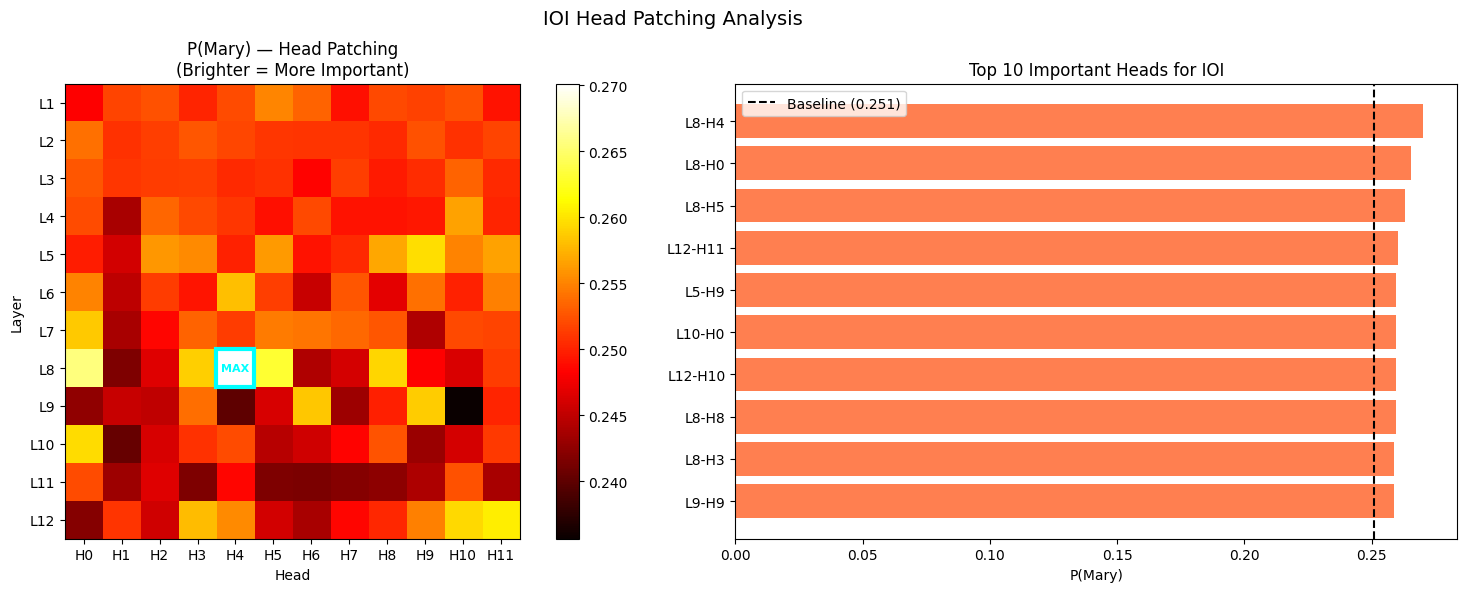


Top 10 heads:
  L8, H4: P(Mary)=0.2701
  L8, H0: P(Mary)=0.2655
  L8, H5: P(Mary)=0.2630
  L12, H11: P(Mary)=0.2605
  L5, H9: P(Mary)=0.2596
  L10, H0: P(Mary)=0.2595
  L12, H10: P(Mary)=0.2595
  L8, H8: P(Mary)=0.2593
  L8, H3: P(Mary)=0.2589
  L9, H9: P(Mary)=0.2587


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
im = axes[0].imshow(kl_matrix.numpy(), 
                     cmap="hot",
                     vmin=kl_matrix.min(),
                     vmax=kl_matrix.max())

axes[0].set_xlabel("Head")
axes[0].set_ylabel("Layer")
axes[0].set_xticks(range(12))
axes[0].set_yticks(range(12))
axes[0].set_xticklabels([f"H{i}" for i in range(12)])
axes[0].set_yticklabels([f"L{i+1}" for i in range(12)])
axes[0].set_title("P(Mary) — Head Patching\n(Brighter = More Important)")

# Best head highlight
max_layer = kl_matrix.max(dim=1).values.argmax().item()
max_head  = kl_matrix[max_layer].argmax().item()
axes[0].add_patch(plt.Rectangle(
    (max_head-0.5, max_layer-0.5), 1, 1,
    fill=False, edgecolor="cyan", linewidth=3))
axes[0].text(max_head, max_layer, "MAX",
             ha="center", va="center",
             color="cyan", fontsize=8, fontweight="bold")
plt.colorbar(im, ax=axes[0])

# Top 10 heads
flat     = kl_matrix.flatten()
top10    = flat.topk(10).indices
top_vals = []
top_labs = []
for idx in top10:
    l = idx // 12
    h = idx % 12
    top_vals.append(kl_matrix[l, h].item())
    top_labs.append(f"L{l+1}-H{h}")

axes[1].barh(top_labs[::-1], top_vals[::-1], color="coral")
axes[1].axvline(x=probs_b[mary_id].item(),
                color="black", linestyle="--",
                label=f"Baseline ({probs_b[mary_id]:.3f})")
axes[1].set_xlabel("P(Mary)")
axes[1].set_title("Top 10 Important Heads for IOI")
axes[1].legend()

plt.suptitle("IOI Head Patching Analysis", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 10 heads:")
for idx in top10:
    l = idx // 12
    h = idx % 12
    print(f"  L{l+1}, H{h}: P(Mary)={kl_matrix[l,h]:.4f}")

* Layer 8, Head 4 is the most important for IOI.
* Layer 8 contains multiple important heads.
* Head-level patching is more specific than layer-level patching.
* “Name Mover Heads” — this is the term used in real research.
